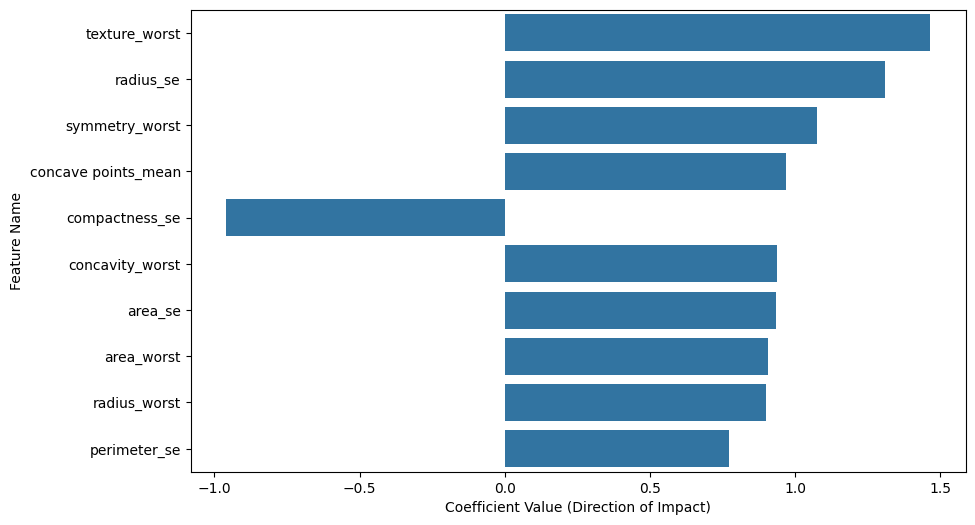

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv('/content/data.csv')
df = df.drop(columns='id')
df = df.drop(columns='Unnamed: 32')
df['diagnosis'] = df['diagnosis'].map({
    'M':1,
    'B':0
})
X= df.drop(columns= 'diagnosis')
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
x_scale = StandardScaler()
X_train = x_scale.fit_transform(X_train)
X_test = x_scale.transform(X_test)
model = LogisticRegression(class_weight= 'balanced',max_iter = 1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

feature_names = X.columns
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False).drop(columns=['Abs_Importance'])

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10),
)
plt.xlabel('Coefficient Value (Direction of Impact)')
plt.ylabel('Feature Name')
plt.show()
